In [1]:
import uproot
import matplotlib.pyplot as plt
import pandas as pd

# Ruta del archivo ROOT
file_path = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/Dewar1m/20251124.root"

# Abrir el archivo
root_file = uproot.open(file_path)

# Mostrar los árboles que contiene
print("Árboles y claves en el ROOT file:")
for key in root_file.keys():
    print(key)


Árboles y claves en el ROOT file:
peak;8
spectrum;3
temp;2


In [2]:
import uproot
root_file = uproot.open("/eos/user/j/jcapotor/FBGdata/ROOTFiles/Dewar1m/20251124.root")

# Árboles principales
trees = ["peak", "spectrum", "temp"]

for tree_name in trees:
    tree = root_file[tree_name]
    print(f"Ramas en el árbol '{tree_name}':")
    print(tree.keys())
    print("-"*40)


Ramas en el árbol 'peak':
['t', 'wav', 'sweep', 'ch', 'pos']
----------------------------------------
Ramas en el árbol 'spectrum':
['t', 'wav']
----------------------------------------
Ramas en el árbol 'temp':
['t', 'temp']
----------------------------------------


In [5]:
import uproot
import numpy as np

# Archivo ROOT de entrada
input_filename = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/Dewar1m/20251124.root"

# Abrir el archivo ROOT con uproot
with uproot.open(input_filename) as file:
    peak_tree = file["peak"]
    spectrum_tree = file["spectrum"]
    temp_tree = file["temp"]
    
    # Cargar ramas como numpy arrays
    peak_data = peak_tree.arrays(library="np")
    spectrum_data = spectrum_tree.arrays(library="np")
    temp_data = temp_tree.arrays(library="np")

# --- Imprimir shapes de todas las variables ---
print("=== peak ===")
for key, value in peak_data.items():
    print(f"{key}: {np.array(value).shape}")

print("\n=== spectrum ===")
for key, value in spectrum_data.items():
    print(f"{key}: {np.array(value).shape}")

print("\n=== temp ===")
for key, value in temp_data.items():
    print(f"{key}: {np.array(value).shape}")



=== peak ===
t: (1832000, 2)
wav: (1832000, 2, 4)
sweep: (1832000, 2, 4)
ch: (1832000, 4)
pos: (1832000, 4)

=== spectrum ===
t: (523, 2)
wav: (523, 2, 3, 39200)

=== temp ===
t: (11578,)
temp: (11578, 5)
wav: (523, 2, 3, 39200)

=== temp ===
t: (11578,)
temp: (11578, 5)


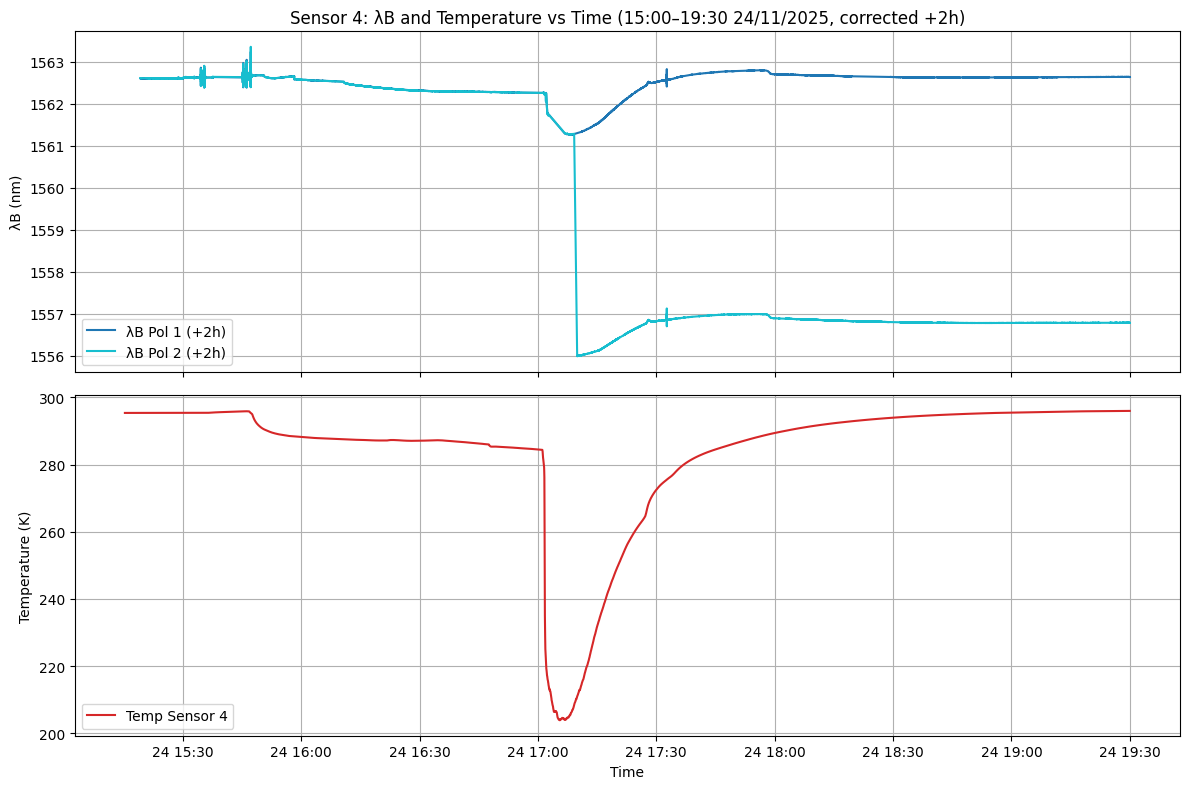

In [6]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import datetime

# --- Abrir archivo ROOT ---
input_filename = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/Dewar1m/20251124.root"

with uproot.open(input_filename) as file:
    peak_tree = file["peak"]
    temp_tree = file["temp"]
    
    peak_data = peak_tree.arrays(library="np")
    temp_data = temp_tree.arrays(library="np")

# --- Sensor 5 ---
peak_times = peak_data["t"][:, 0]           # primera polarización
sensor3_pol1 = peak_data["wav"][:, 0, 3]
sensor3_pol2 = peak_data["wav"][:, 1, 3]

temp_times = temp_data["t"]
sensor3_temp = temp_data["temp"][:, 3]

# --- Convertir tiempos a datetime ---
peak_timestamps = np.array([datetime.datetime.utcfromtimestamp(t) for t in peak_times])
temp_timestamps = np.array([datetime.datetime.utcfromtimestamp(t) for t in temp_times])

# --- 💡 Corregir desfase: sumar 2 horas a los tiempos de peak ---
time_shift = datetime.timedelta(hours=2) - datetime.timedelta(minutes=1)
peak_timestamps = peak_timestamps + time_shift

# --- Definir filtro temporal ---
start_time = datetime.datetime(2025, 11, 24, 15, 0, 0)
end_time   = datetime.datetime(2025, 11, 24, 19, 30, 0)

# --- Aplicar máscaras ---
mask_peak = (peak_timestamps >= start_time) & (peak_timestamps <= end_time)
peak_t_filtered = peak_timestamps[mask_peak]
sensor3_pol1_filtered = sensor3_pol1[mask_peak]
sensor3_pol2_filtered = sensor3_pol2[mask_peak]

mask_temp = (temp_timestamps >= start_time) & (temp_timestamps <= end_time)
temp_t_filtered = temp_timestamps[mask_temp]
sensor3_temp_filtered = sensor3_temp[mask_temp]

# --- Filtrar valores nulos o cero en el pico (λB) ---
valid_mask = (sensor3_pol1_filtered != 0) & (sensor3_pol2_filtered != 0) & (~np.isnan(sensor3_pol1_filtered)) & (~np.isnan(sensor3_pol2_filtered))
peak_t_filtered = peak_t_filtered[valid_mask]
sensor3_pol1_filtered = sensor3_pol1_filtered[valid_mask]
sensor3_pol2_filtered = sensor3_pol2_filtered[valid_mask]

# --- Graficar en dos subplots ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12,8), sharex=True)

# λB
ax1.plot(peak_t_filtered, sensor3_pol1_filtered*1e9, label="λB Pol 1 (+2h)", color="tab:blue")
ax1.plot(peak_t_filtered, sensor3_pol2_filtered*1e9, label="λB Pol 2 (+2h)", color="tab:cyan")
ax1.set_ylabel("λB (nm)")
ax1.set_title("Sensor 4: λB and Temperature vs Time (15:00–19:30 24/11/2025, corrected +2h)")
ax1.legend()
ax1.grid(True)

# Temperatura
ax2.plot(temp_t_filtered, sensor3_temp_filtered, label="Temp Sensor 4", color="tab:red")
ax2.set_xlabel("Time")
ax2.set_ylabel("Temperature (K)")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()


Solo tomamos la primera polarizacion ya que la segunda intenta buscar un pico irreal. Además, agregamos el sensor 5 a mitad del procesamiento de los datos. Hay que revisar en el convertidor si esto es un error al cambiar el número de sensores. Fue un enfriamiento y calentamiento rápidos usando un poco de nitrógeno que le sobró a Carlos en su ranger de Massibo. Los fits proporcionados por el DAQ no son buenos, habría que mirar los espectros. De hecho, en la estructura de 'wav' vemos que hay solo 4 sensores, eso es porque el programa no admite modificaciones a posteriori y se han mezclado los sensores.

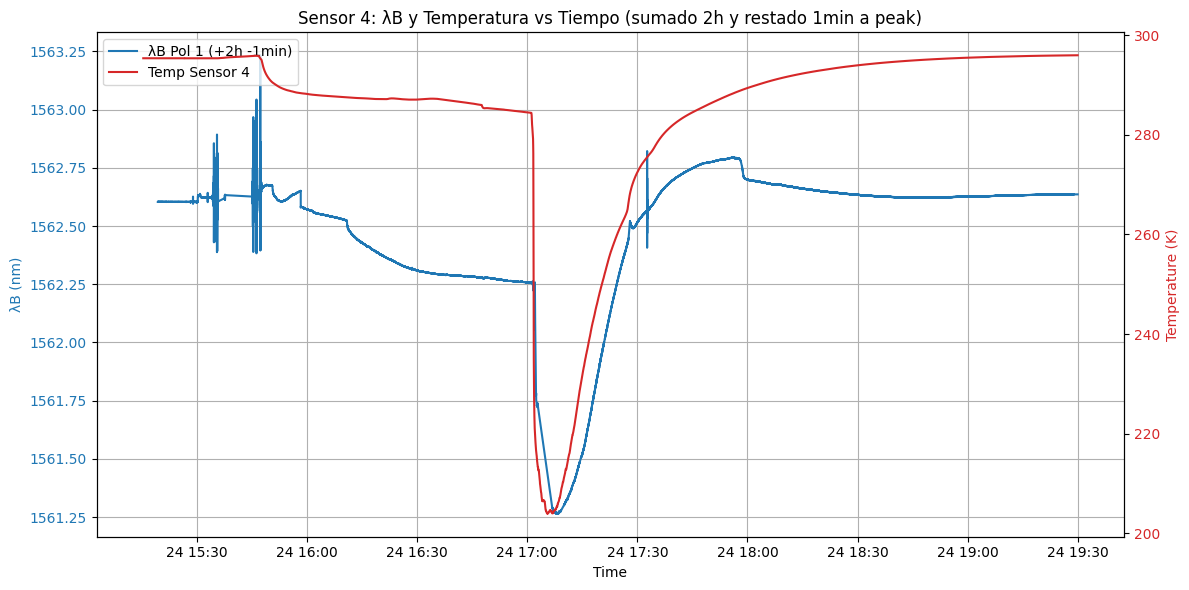

In [9]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import datetime

# --- Abrir archivo ROOT ---
input_filename = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/Dewar1m/20251124.root"

with uproot.open(input_filename) as file:
    peak_tree = file["peak"]
    temp_tree = file["temp"]
    
    peak_data = peak_tree.arrays(library="np")
    temp_data = temp_tree.arrays(library="np")

# --- Sensor 5 ---
peak_times = peak_data["t"][:, 0]           # primera polarización
sensor3_pol1 = peak_data["wav"][:, 0, 3]

temp_times = temp_data["t"]
sensor3_temp = temp_data["temp"][:, 3]

# --- Convertir tiempos a datetime ---
peak_timestamps = np.array([datetime.datetime.utcfromtimestamp(t) for t in peak_times])
temp_timestamps = np.array([datetime.datetime.utcfromtimestamp(t) for t in temp_times])

# --- 💡 Corregir desfase: sumar 2 horas y restar 1 minuto a los tiempos de peak ---
time_shift = datetime.timedelta(hours=2) - datetime.timedelta(minutes=1)
peak_timestamps = peak_timestamps + time_shift

# --- Definir filtro temporal ---
start_time = datetime.datetime(2025, 11, 24, 15, 0, 0)
end_time   = datetime.datetime(2025, 11, 24, 19, 30, 0)

# --- Aplicar máscaras ---
mask_peak = (peak_timestamps >= start_time) & (peak_timestamps <= end_time)
peak_t_filtered = peak_timestamps[mask_peak]
sensor3_pol1_filtered = sensor3_pol1[mask_peak]

mask_temp = (temp_timestamps >= start_time) & (temp_timestamps <= end_time)
temp_t_filtered = temp_timestamps[mask_temp]
sensor3_temp_filtered = sensor3_temp[mask_temp]

# --- Filtrar valores nulos o cero en el pico (λB) ---
valid_mask = (sensor3_pol1_filtered != 0) & (~np.isnan(sensor3_pol1_filtered))
peak_t_filtered = peak_t_filtered[valid_mask]
sensor3_pol1_filtered = sensor3_pol1_filtered[valid_mask]

# --- Graficar ambos datos en un solo subplot con dos ejes y leyendas ---
fig, ax1 = plt.subplots(figsize=(12,6))

color1 = "tab:blue"
color2 = "tab:red"

# λB (eje izquierdo)
ax1.plot(peak_t_filtered, sensor3_pol1_filtered*1e9, label="λB Pol 1 (+2h -1min)", color=color1)
ax1.set_ylabel("λB (nm)", color=color1)
ax1.tick_params(axis='y', labelcolor=color1)

# Título con info de la corrección
ax1.set_title("Sensor 4: λB y Temperatura vs Tiempo (sumado 2h y restado 1min a peak)")

# Temperatura (eje derecho)
ax2 = ax1.twinx()
ax2.plot(temp_t_filtered, sensor3_temp_filtered, label="Temp Sensor 4", color=color2)
ax2.set_ylabel("Temperature (K)", color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

# Leyendas
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper left")

ax1.set_xlabel("Time")
ax1.grid(True)

plt.tight_layout()
plt.show()

---- DATA TIME INTERVALS ----
Peak data (+2h): 2025-11-24 15:19:17.734447002  →  2025-11-24 19:31:12.638992071
Temp data:       2025-11-24 15:15:19  →  2025-11-24 19:30:11
--------------------------------


===== SENSOR 1 =====
λB range: 1544.991–1545.369 nm
T range:  288.99–292.08 K
Fit data points: 10
x mean ± std: 290.383 ± 0.874 K
y mean ± std: 1545198.548 ± 108.489 pm
Fit slope = 8.0493e+01 pm/K, Intercept = 1.5218e+06 pm

===== SENSOR 3 =====
λB range: 1556.390–1556.855 nm
T range:  270.17–280.57 K
Fit data points: 10
x mean ± std: 275.091 ± 2.955 K
y mean ± std: 1556648.037 ± 137.524 pm
Fit slope = 3.5410e+01 pm/K, Intercept = 1.5469e+06 pm

===== SENSOR 4 =====
λB range: 1561.928–1562.521 nm
T range:  249.09–272.45 K
Fit data points: 10
x mean ± std: 260.976 ± 6.535 K
y mean ± std: 1562273.381 ± 180.489 pm
Fit slope = 2.1873e+01 pm/K, Intercept = 1.5566e+06 pm


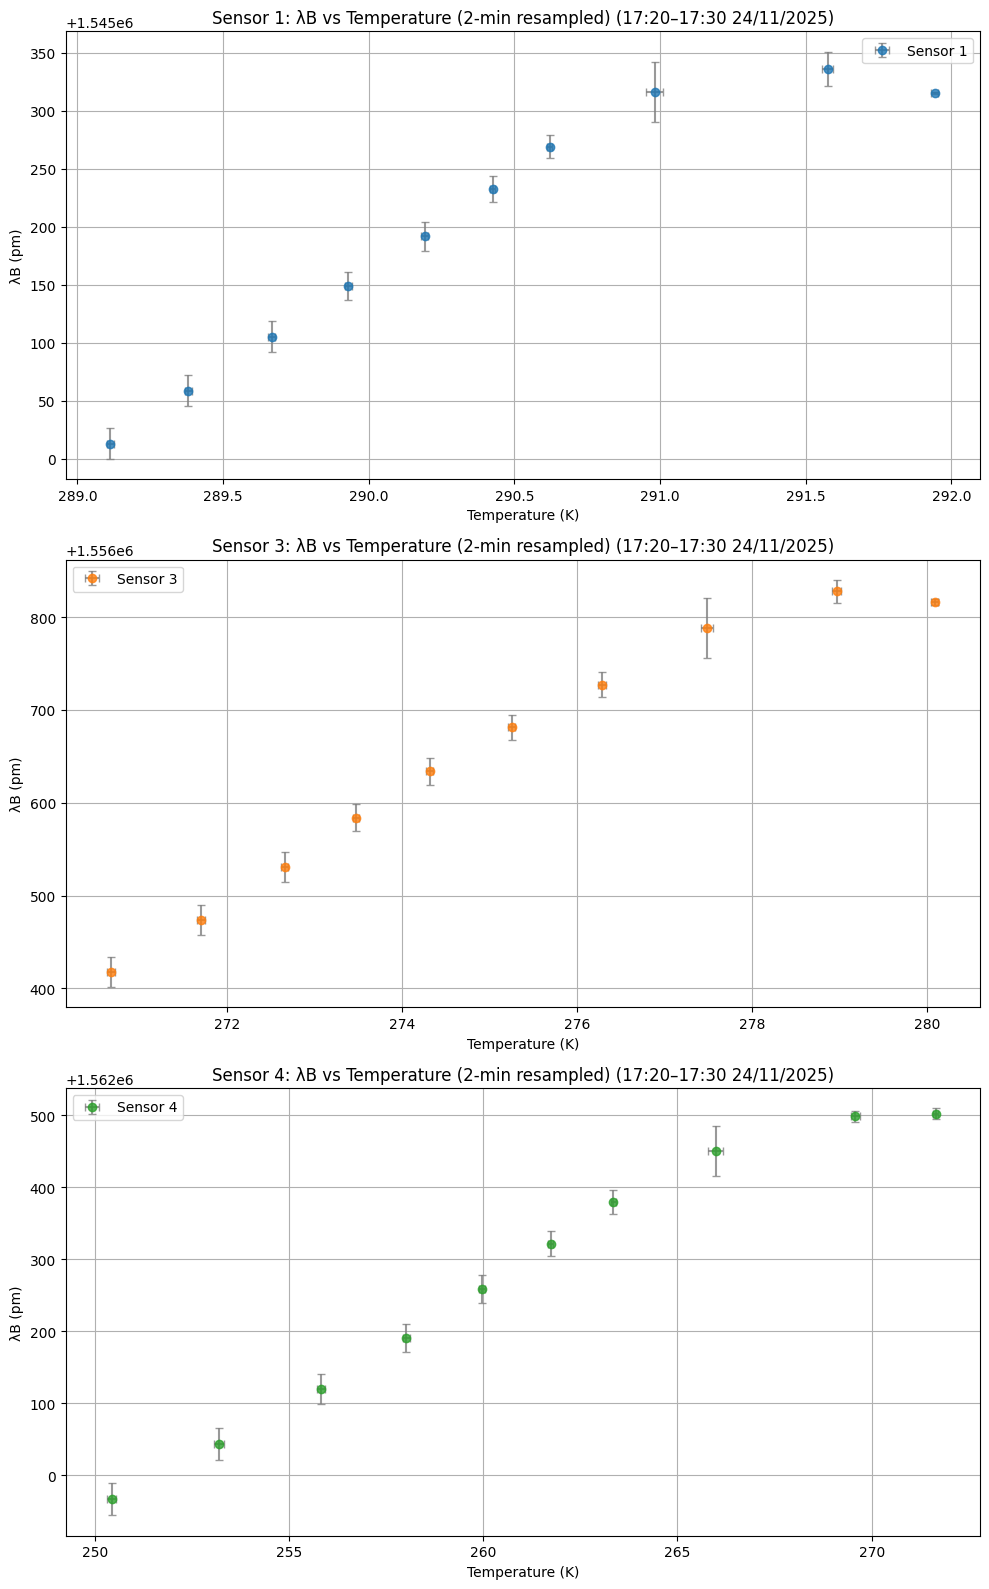

In [4]:
import uproot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime

# --- Open ROOT file ---
input_filename = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/Dewar1m/20251124.root"
with uproot.open(input_filename) as file:
    peak_tree = file["peak"]
    temp_tree = file["temp"]
    peak_data = peak_tree.arrays(library="np")
    temp_data = temp_tree.arrays(library="np")

# --- Sensors to analyze (1,3,4) ---
sensors = [0, 2, 3]

# --- Convert timestamps ---
peak_times = pd.to_datetime(peak_data["t"][:, 0], unit='s')
temp_times = pd.to_datetime(temp_data["t"], unit='s')

# --- ✅ Apply +2 hour correction to peak timestamps ---
time_shift = datetime.timedelta(hours=2) - datetime.timedelta(minutes=1) 
peak_times = peak_times + time_shift

# --- Print data intervals for sanity check ---
print("---- DATA TIME INTERVALS ----")
print(f"Peak data (+2h): {peak_times.min()}  →  {peak_times.max()}")
print(f"Temp data:       {temp_times.min()}  →  {temp_times.max()}")
print("--------------------------------\n")

# --- Time window ---
start_time = datetime.datetime(2025, 11, 24, 17, 20, 0)
end_time   = datetime.datetime(2025, 11, 24, 17, 30, 0)

mask_peak = (peak_times >= start_time) & (peak_times <= end_time)
mask_temp = (temp_times >= start_time) & (temp_times <= end_time)

peak_t_filtered = peak_times[mask_peak]
temp_t_filtered = temp_times[mask_temp]

# --- Fixed colors per sensor ---
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]

# --- Create figure ---
fig, axes = plt.subplots(len(sensors), 1, figsize=(10, 16))

for i, sensor in enumerate(sensors):
    print(f"\n===== SENSOR {sensor+1} =====")
    
    # λB from both polarizations (meters -> nm)
    lambdaB_m = (peak_data["wav"][:, 0, sensor] ) # meters
    lambdaB_nm = lambdaB_m * 1e9  # nanometers
    lambdaB_filtered = lambdaB_nm[mask_peak]
    
    # Quick check of magnitude
    print(f"λB range: {lambdaB_filtered.min():.3f}–{lambdaB_filtered.max():.3f} nm")
    
    # Temperature
    temp_sensor = temp_data["temp"][:, sensor]
    temp_filtered = temp_sensor[mask_temp]
    print(f"T range:  {temp_filtered.min():.2f}–{temp_filtered.max():.2f} K")

    # DataFrames
    df_peak = pd.DataFrame({"lambdaB_nm": lambdaB_filtered}, index=peak_t_filtered)
    df_temp = pd.DataFrame({"temp_K": temp_filtered}, index=temp_t_filtered)
    
    # Resample every 2 minutes → mean & std
    peak_resampled = df_peak.resample("1min").agg(["mean","std"])
    temp_resampled = df_temp.resample("1min").agg(["mean","std"])
    
    # Standard error of the mean
    peak_resampled['lambdaB_nm','se'] = peak_resampled['lambdaB_nm','std'] / np.sqrt(df_peak.resample("1min").count()['lambdaB_nm'])
    temp_resampled['temp_K','se'] = temp_resampled['temp_K','std'] / np.sqrt(df_temp.resample("1min").count()['temp_K'])
    
    # Merge and drop NaN
    df_combined = pd.concat([peak_resampled, temp_resampled], axis=1).dropna()
    
    # --- Weighted linear fit but with swapped axes: x = Temperature (K), y = λB (pm) ---
    # Convert λB to pm for y
    x = df_combined['temp_K','mean'].values            # K (x-axis)
    y = df_combined['lambdaB_nm','mean'].values * 1e3  # pm (y-axis)

    # uncertainties on y (lambdaB) converted to pm
    yerr = df_combined['lambdaB_nm','std'].values * 1e3  # pm
    # x uncertainties for plotting (optional)
    xerr = df_combined['temp_K','se'].values

    # Basic sanity check
    print(f"Fit data points: {len(x)}")
    if len(x) > 0:
        print(f"x mean ± std: {np.mean(x):.3f} ± {np.std(x):.3f} K")
        print(f"y mean ± std: {np.mean(y):.3f} ± {np.std(y):.3f} pm")

    # avoid zero-division in weights
    if np.all(yerr == 0) or len(yerr)==0:
        w = None
        slope, intercept = np.polyfit(x, y, 1)
    else:
        yerr_safe = np.where(yerr == 0, np.mean(yerr[yerr>0]) if np.any(yerr>0) else 1.0, yerr)
        w = 1.0 / (yerr_safe ** 2)
        slope, intercept = np.polyfit(x, y, 1, w=w)

    # slope is in pm/K directly
    print(f"Fit slope = {slope:.4e} pm/K, Intercept = {intercept:.4e} pm")

    # Plot: Temperature on x, λB on y (pm)
    ax = axes[i]
    ax.errorbar(x, y, xerr=xerr, yerr=yerr, fmt='o', color=colors[i], ecolor='gray', capsize=3, alpha=0.8, label=f"Sensor {sensor+1}")

    # plot fit line over sorted x for nicer visualization
    if len(x) > 0:
        x_sort_idx = np.argsort(x)
        x_sorted = x[x_sort_idx]
        #ax.plot(x_sorted, slope * x_sorted + intercept, '-', color=colors[i], label=f"Fit: {slope:.2f} pm/K")

    ax.set_xlabel("Temperature (K)")
    ax.set_ylabel("λB (pm)")
    ax.set_title(f"Sensor {sensor+1}: λB vs Temperature (2-min resampled) (17:20–17:30 24/11/2025)")
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()